Machine Learning Model 
Building a model to predict  who will churn
A classification modelling approach will be  implemented using Scikit-learn to predict customer churn.
Logistic Regression was selected as the baseline model due to its interpretability and suitability for binary classification problems. The model estimates churn probability based on behavioural and demographic predictors.

Model performance will be  evaluated using classification metrics and ROC-AUC analysis, and feature importance will be  examined to identify key churn drivers.

In [70]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [71]:
# Load Data
df_BankChurn = pd.read_csv("../DataSet/Cleaned/BankChurners_Cleaned.csv")

df_BankChurn.shape


(10127, 28)

In [72]:
# Define Target and Features
#Target = Churn_Flag
# Feature = all other useful columns
#  Drop unwanted columns
y = df_BankChurn["Churn_Flag"]

# Features (drop target + IDs)
X = df_BankChurn.drop(columns=[
    "Churn_Flag",       # Target
    "Attrition_Flag",   # Orignal churn label, it has the same information as the churn_Flag
    "CLIENTNUM"         # ID column
])


In [73]:
X.shape
X.columns

Index(['Customer_Age', 'Gender', 'Dependent_count', 'Education_Level',
       'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Tenure_Band', 'Age_Band', 'Utilisation_Segment', 'Activity_Level',
       'Spend_Drop_Flag', 'Transaction_Drop_Flag'],
      dtype='object')

In [74]:
# Splitting the Train and Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts(normalize=True).round(3), y_test.value_counts(normalize=True).round(3)

(Churn_Flag
 0    0.839
 1    0.161
 Name: proportion, dtype: float64,
 Churn_Flag
 0    0.84
 1    0.16
 Name: proportion, dtype: float64)

A stratified train-test split was applied to preserve the churn class distribution across both datasets. This ensures that the model is trained and evaluated on representative samples, preventing bias caused by class imbalance.

In [75]:
# Identify Categorical columns
categorical_cols = X_train.select_dtypes(include="object").columns.tolist()
numeric_cols = X_train.select_dtypes(exclude="object").columns.tolist()

categorical_cols, numeric_cols

(['Gender',
  'Education_Level',
  'Marital_Status',
  'Income_Category',
  'Card_Category',
  'Tenure_Band',
  'Age_Band',
  'Utilisation_Segment',
  'Activity_Level'],
 ['Customer_Age',
  'Dependent_count',
  'Months_on_book',
  'Total_Relationship_Count',
  'Months_Inactive_12_mon',
  'Contacts_Count_12_mon',
  'Credit_Limit',
  'Total_Revolving_Bal',
  'Avg_Open_To_Buy',
  'Total_Amt_Chng_Q4_Q1',
  'Total_Trans_Amt',
  'Total_Trans_Ct',
  'Total_Ct_Chng_Q4_Q1',
  'Avg_Utilization_Ratio',
  'Spend_Drop_Flag',
  'Transaction_Drop_Flag'])

In [76]:
# Processing Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

A machine pipeline was built to automate preprocessing and model training. Categorical variables were encoded, while numerical variables were passed through unchanged. 

In [77]:


pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

# Train 
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Education_Level',
                                                   'Marital_Status',
                                                   'Income_Category',
                                                   'Card_Category',
                                                   'Tenure_Band', 'Age_Band',
                                                   'Utilisation_Segment',
                                                   'Activity_Level'])])),
                ('model', LogisticRegression(max_iter=1000))])

A machine learning pipeline was implemented using Scikit-learn.
Categorical variables were encoded using OneHotEncoder within a ColumnTransformer, while numerical features were passed through unchanged. The transformed data was then used to train a Logistic Regression classifier to predict customer churn.
This pipeline automates preprocessing and model training in a single workflow.

Machine Learning Evaluation 

In [78]:
# Testing the model - Classification Report 
y_pred = pipeline.predict(X_test)


In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      1701
           1       0.78      0.59      0.67       325

    accuracy                           0.91      2026
   macro avg       0.85      0.78      0.81      2026
weighted avg       0.90      0.91      0.90      2026



Model Interpretation 
The model achieved an overall accuracy of 91%. 

It performs strongly in identifying non-churn customers, with a recall of 97%. However, performance on churn prediction is lower, with a recall of 59%, meaning some at-risk customers are not detected. Despite this, the model provides valuable early-warning signals for customer churn.

This suggests the model is conservative in predicting churn, prioritising precision over recall. Future improvements could include class balancing or advanced algorithms to enhance churn detection.

In [80]:
# Confusion Matrix- This will predict the accuracy breakdown
con_mat= confusion_matrix(y_test, y_pred)
con_mat

array([[1648,   53],
       [ 134,  191]], dtype=int64)

The confusion matrix provides a detailed breakdown of model predictions.

The model correctly identified 1,648 retained customers and 191 churned customers. However, 134 churners were misclassified as retained customers, indicating some missed churn risks. Additionally, 53 customers were incorrectly predicted to churn.

Overall, the model demonstrates strong capability in identifying retained customers, with moderate effectiveness in detecting churners. This suggests the model can support proactive retention strategies but may benefit from further optimisation to reduce missed churn cases.

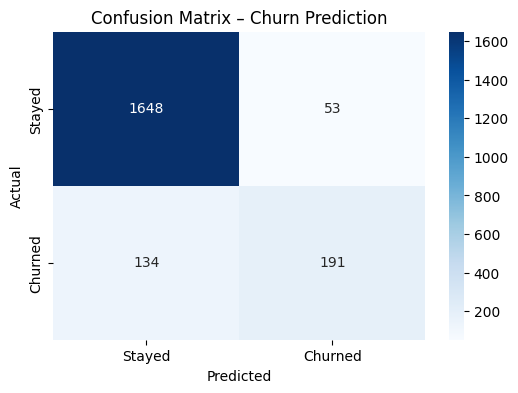

In [81]:
# Visual Confusion Matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    con_mat,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

plt.title("Confusion Matrix – Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix Visual Interpretation 
The confusion matrix provides a breakdown of model predictions.
The model correctly classified the majority of non-churn customers. However, 134 churners were misclassified as retained customers, indicating room for improvement in churn detection.
This aligns with the classification report, where churn recall was lower than non-churn recall.
Churn detection rate = 191 / (191 + 134) = 59%
Stayed detection rate = 1648 / (1648 + 53) = 97%

The model is highly reliable in identifying loyal customers. While churn detection is lower, it still provides valuable early-warning signals that can guide targeted retention campaigns.


Probability Performance
This will be performed using ROC AUC (Receiver Operating Charactristic Area Under the Curve), a performance metric for binary classification problems that measures a model’s ability to distinguish between classes across all thresholds

In [82]:
# ROC-AUC (Receiver Operating Charateristic Area Under the Curve) 
y_prob = pipeline.predict_proba(X_test)[:, 1]

In [83]:
roc_auc_score(y_test, y_prob)

0.9322498078053633

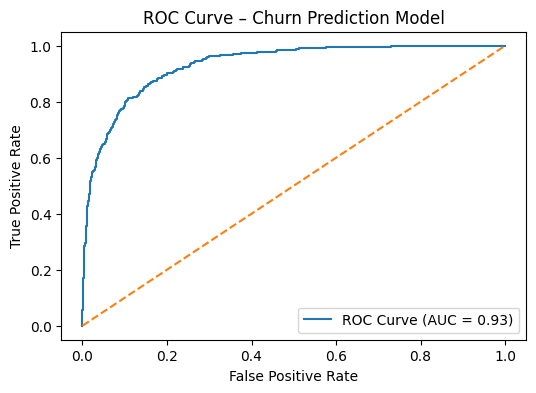

In [87]:
# ROC Curve Visual
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="ROC Curve (AUC = 0.93)")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve – Churn Prediction Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

The ROC-AUC score of 0.93 indicates excellent model performance in distinguishing churners from retained customers.

This suggests the model has strong predictive capability and can effectively rank customers by churn risk. While recall for churn detection was moderate, the high ROC-AUC score demonstrates that the model’s probability predictions are highly reliable for identifying at-risk customers.

This indicate that the model can be used as an early-warning system to prioritise high-risk customers for retention interventions.


FEATURE IMPORTANCE 
The Feature importance will answer  ; 

“Which variables influence churn prediction the most?

In [88]:
churn_features = pipeline.named_steps["preprocessor"].get_feature_names_out()

churn_coefficients = pipeline.named_steps["model"].coef_[0]

feature_importance_df = pd.DataFrame({
    "Churn_Driver": churn_features,
    "Impact_Score": churn_coefficients
}).sort_values(by="Impact_Score", ascending=False)

feature_importance_df.head(15)

,Churn_Driver,Impact_Score
28,cat__Activity_Level_Medium,1.565548
44,remainder__Transaction_Drop_Flag,0.897709
33,remainder__Months_Inactive_12_mon,0.758037
34,remainder__Contacts_Count_12_mon,0.678691
8,cat__Marital_Status_Single,0.471111
43,remainder__Spend_Drop_Flag,0.459312
13,cat__Income_Category_Less than $40K,0.419313
22,cat__Age_Band_41-50,0.401975
21,cat__Age_Band_31-40,0.338916
18,cat__Tenure_Band_2-3 years,0.233258


Feature Importance Interpretation 
Feature importance analysis revealed that behavioural engagement variables were the strongest predictors of churn. Medium activity levels, transaction drops, and inactivity months had the highest positive coefficients, indicating increased churn risk.
Demographic factors such as marital status, income level, and age also influenced churn likelihood, though to a lesser degree.
Additionally, low credit utilisation emerged as a churn indicator, suggesting disengagement from credit usage.
Overall, the model confirms that behavioural signals are more predictive of churn than static demographic attributes.
